# Lab 03 — Search Engineering: Package, Tests, CLI and Benchmark

The search code from Labs 1–2 lives in the small package `all_experiments/utils/`. This
notebook checks its interface, runs its unit tests, drives it from the command line and
benchmarks four algorithms on ten real route queries.

**How to run.** Open this notebook from the `all_experiments` folder and choose *Run All*.
Evidence is written to `results/lab03/`.

**Questions**

1. Standardise the interface.
2. Separate responsibilities into modules.
3. Run the automated tests.
4. Exercise the command-line interface.
5. Benchmark ten route pairs.
6. Save the evidence.

## Setup

In [1]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import utils
from utils import SearchResult, bfs, dfs, ucs, gbfs, astar, haversine_km, load_openflights

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab03"
RESULTS.mkdir(parents=True, exist_ok=True)

## Question 1 — Standardise the interface

Every algorithm must return the same fields. Show the fields of `SearchResult`, then run all
five algorithms on a small hand-made graph and display the results as one table.

In [2]:
print("SearchResult fields:", list(SearchResult.__dataclass_fields__))

toy = {"S": [("A", 2.0), ("B", 5.0)], "A": [("G", 5.0)], "B": [("G", 1.0)], "G": []}
h = {"S": 5.0, "A": 4.0, "B": 1.0, "G": 0.0}.get      # a hand-made admissible heuristic

results = {
    "BFS": bfs(toy, "S", "G"),
    "DFS": dfs(toy, "S", "G"),
    "UCS": ucs(toy, "S", "G"),
    "GBFS": gbfs(toy, "S", "G", h),
    "A*": astar(toy, "S", "G", h),
}
table = pd.DataFrame({name: r.as_dict() for name, r in results.items()}).T.drop(columns="runtime_ms")
table["path"] = table.path.map(" -> ".join)
display(table)

SearchResult fields: ['found', 'path', 'hops', 'path_cost_km', 'expanded', 'max_frontier', 'runtime_ms']


,found,path,hops,path_cost_km,expanded,max_frontier
BFS,True,S -> A -> G,2,7.0,3,2
DFS,True,S -> A -> G,2,7.0,2,2
UCS,True,S -> B -> G,2,6.0,3,2
GBFS,True,S -> B -> G,2,6.0,2,2
A*,True,S -> B -> G,2,6.0,3,2


**Answer.** All five functions return a `SearchResult` with identical fields, so one loop
can benchmark them. On the toy graph BFS and DFS return the two-edge route S → A → G (cost
7) while UCS and A* return the cheaper S → B → G (cost 6); GBFS also picks S → B → G because
$h(B) < h(A)$.

## Question 2 — Separate responsibilities

Search logic, data loading, plotting and the command line must live in separate modules.
List the package's modules with their one-line purpose, and the names it exports.

In [3]:
package = Path(utils.__file__).parent
for module in sorted(package.glob("*.py")):
    purpose = module.read_text(encoding="utf-8").splitlines()[0].strip('"')
    print(f"{module.name:<16} {purpose}")
print("\nExported names:", ", ".join(utils.__all__))

__init__.py      Helper code for the AI course notebooks.
__main__.py      Command-line route search (Lab 3).
core.py          Graph-search algorithms shared by Labs 1-3: BFS, DFS, UCS, GBFS and A*.
openflights.py   Load the OpenFlights airport and route files into a weighted graph.
plotting.py      Plot airport routes on longitude/latitude axes (Labs 1-3).
test_search.py   Unit tests for utils.core on tiny hand-made graphs (no dataset needed).

Exported names: SearchResult, astar, best_first, bfs, dfs, gbfs, ucs, haversine_km, load_openflights, route_is_valid, plot_route_paths


**Answer.** `core.py` holds the five algorithms and knows nothing about airports;
`openflights.py` cleans the CSV files and computes distances; `plotting.py` draws routes;
`__main__.py` is the command line; `test_search.py` holds the tests. Each module can be
changed and tested on its own.

## Question 3 — Run the automated tests

The tests use tiny hand-made graphs and cover start = goal, unreachable goal, cycles,
different objectives, frontier updates, admissible A*, non-optimal GBFS and negative costs.
Run them with pytest from inside the notebook.

In [4]:
tests = subprocess.run([sys.executable, "-m", "pytest", "utils", "-q", "--color=no"], capture_output=True, text=True)
print(tests.stdout)
assert tests.returncode == 0, tests.stderr

........                                                                 [100%]
8 passed in 0.51s



**Answer.** All eight tests pass in under a second. They need no dataset, so they run
anywhere — including a continuous-integration server.

## Question 4 — Exercise the command-line interface

Run `python -m utils --algorithm astar --start KUL --goal KEF` as a subprocess and show
its output.

In [5]:
cli = subprocess.run([sys.executable, "-m", "utils", "--algorithm", "astar", "--start", "KUL", "--goal", "KEF"],
                     capture_output=True, text=True)
print(cli.stdout)
assert cli.returncode == 0, cli.stderr

ASTAR: found=True, hops=4, cost_km=11461.3, expanded=69, runtime_ms=3.50
KUL -> HKT -> LED -> HEL -> KEF



**Answer.** The command line prints the same KUL → HKT → LED → HEL → KEF route and
11,461 km that Lab 2 found: the notebook and the terminal share one implementation.

## Question 5 — Benchmark ten route pairs

Run BFS, UCS, GBFS and A* on the ten queries in `utils/search_queries.csv` and summarise
success rate, mean cost, mean hops, expanded nodes and runtime per algorithm. Save
`benchmark.csv` and `benchmark_summary.csv`.

In [6]:
_, _, coords, graph, _ = load_openflights(DATA / "lab01-03_airports.csv", DATA / "lab01-03_routes.csv")
queries = pd.read_csv("utils/search_queries.csv")


def heuristic_to(goal):
    return lambda a: haversine_km(coords[a]["latitude"], coords[a]["longitude"], coords[goal]["latitude"], coords[goal]["longitude"])


rows = []
for query in queries.itertuples():
    h = heuristic_to(query.goal)
    results = {"BFS": bfs(graph, query.start, query.goal), "UCS": ucs(graph, query.start, query.goal),
               "GBFS": gbfs(graph, query.start, query.goal, h), "A*": astar(graph, query.start, query.goal, h)}
    for name, result in results.items():
        rows.append({"query_id": query.query_id, "start": query.start, "goal": query.goal, "algorithm": name,
                     **result.as_dict(), "path": " -> ".join(result.path)})

benchmark = pd.DataFrame(rows).rename(columns={"path_cost_km": "cost_km"})
benchmark.to_csv(RESULTS / "benchmark.csv", index=False)
summary = benchmark.groupby("algorithm").agg(success_rate=("found", "mean"), mean_cost_km=("cost_km", "mean"),
                                             mean_hops=("hops", "mean"), mean_expanded=("expanded", "mean"),
                                             median_runtime_ms=("runtime_ms", "median")).round(2)
summary.to_csv(RESULTS / "benchmark_summary.csv")
display(summary)

costs = benchmark.pivot(index="query_id", columns="algorithm", values="cost_km")
print("A* cost equals UCS on all 10 queries:", np.allclose(costs["A*"], costs["UCS"]))
print("GBFS is costlier than UCS on", int((costs["GBFS"] > costs["UCS"] + 1e-6).sum()), "of 10 queries")

,success_rate,mean_cost_km,mean_hops,mean_expanded,median_runtime_ms
algorithm,,,,,
A*,1.0,14321.11,2.2,62.7,3.09
BFS,1.0,16469.27,1.8,323.9,3.39
GBFS,1.0,15087.33,2.1,2.1,2.89
UCS,1.0,14321.11,2.2,2700.4,7.13


A* cost equals UCS on all 10 queries: True
GBFS is costlier than UCS on 7 of 10 queries


**Answer.** Every algorithm succeeds on all ten queries. A* matches the UCS cost on every
query with a fraction of the expansions; BFS has the highest mean cost because it optimises
hops; GBFS expands the fewest states but returns a costlier route on seven queries. For
distance-based routing A* is the best default among the exact methods.

## Question 6 — Save the evidence

Save a bar chart of mean expansions per algorithm. Then note the one-line terminal command
that runs the same tests outside the notebook.

Saved: ['benchmark.csv', 'benchmark_expansions.png', 'benchmark_summary.csv']
Terminal command (from all_experiments):  python -m pytest utils -q


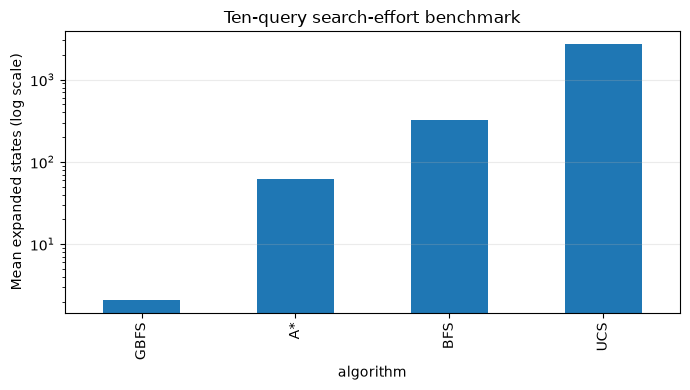

In [7]:
ax = summary.mean_expanded.sort_values().plot.bar(figsize=(7, 4), logy=True)
ax.set(ylabel="Mean expanded states (log scale)", title="Ten-query search-effort benchmark")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS / "benchmark_expansions.png", dpi=160)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))
print("Terminal command (from all_experiments):  python -m pytest utils -q")

**Answer.** Evidence: `results/lab03/benchmark.csv`, `benchmark_summary.csv`,
`benchmark_expansions.png` and this executed notebook. `python -m pytest utils -q` runs
the same tests from a clean checkout, which is exactly what a continuous-integration job
would do.